In [1]:
import torch
from torch import nn

from aif import SGD, DataModule, Module, Trainer

# LinearRegression from Scratch

In [2]:
class SyntheticRegressionData(DataModule):
    def __init__(self, w, b, noise=0.01, num_train=1200, num_val=800, batch_size=32):
        super().__init__(batch_size=batch_size)
        
        self.w = w
        self.b = b
        self.noise = noise
        self.num_train = num_train
        self.num_val = num_val
        
        self.n = num_train + num_val
        self.d = len(w)

        self.X = torch.randn(self.n, self.d)
        e = torch.randn(self.n, 1) * self.noise

        self.y = (self.X @ self.w.reshape((-1, 1))) + self.b + e

    def get_dataloader(self, train):
        indices = slice(0, self.num_train) if train else slice(self.num_train, self.n)
        
        return self._get_tensorloader((self.X, self.y), train, indices=indices)

In [3]:
class LinearRegressionScratch(Module):
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__(lr)
        
        self.num_inputs = num_inputs
        self.sigma = sigma
        
        self.w = nn.Parameter(torch.normal(0, sigma, (num_inputs, 1)))
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, X):
        return (X @ self.w) + self.b

    def loss(self, y_hat, y):
        l = ((y_hat - y) ** 2) / 2
        
        return l.mean()

    def configure_optimizers(self):
        return SGD(self.parameters(), self.lr)

## Prepare Dataset
- Load/Synthesize Data
- Train/Val Batch Split

In [4]:
w = torch.tensor([2, -3.4])
b = 4.2

data = SyntheticRegressionData(w, b)

train_batches = data.get_dataloader(True)
val_batches = data.get_dataloader(False)

len(train_batches), len(val_batches)

(38, 25)

## Training

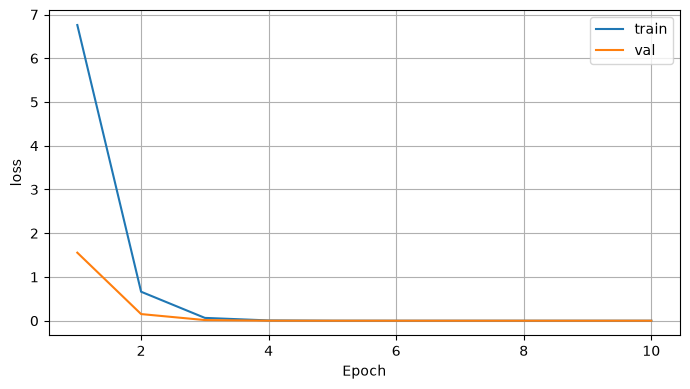

Epoch 10/10 | train_loss: 0.000053 | val_loss: 0.000049


In [5]:
num_inputs = len(w)
model = LinearRegressionScratch(num_inputs, 0.03)

trainer = Trainer(max_epochs=10)
trainer.fit(model, data)

In [6]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([-0.0001, -0.0004])
error in estimating b: tensor([-0.0001])


In [7]:
with torch.no_grad():
    print(f'Original w: {[i.item() for i in data.w]}')
    print(f'Model w: {[i.item() for i in model.w]}')
    print(f'Original b: {data.b}')
    print(f'Model b: {model.b.item()}')

Original w: [2.0, -3.4000000953674316]
Model w: [2.000143051147461, -3.3996121883392334]
Original b: 4.2
Model b: 4.200132846832275


## Inference

In [8]:
val_batch = next(iter(val_batches))
X, y = val_batch[0], val_batch[1]

with torch.no_grad():
    y_hat = model(X)
    print(f'Input features: {[x.item() for x in X[0]]}')
    print(f'Target: \n- Actual: {y[0].item()} \n- Predicted: {y_hat[0].item()}')

Input features: [0.8990206122398376, -1.021959900856018]
Target: 
- Actual: 9.472482681274414 
- Predicted: 9.472570419311523


# LinearRegression using PyTorch

In [9]:
class LinearRegression(Module):
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__(lr)

        self.net = nn.Linear(num_inputs, 1)

        self.net.weight.data.normal_(0, sigma)
        self.net.bias.data.fill_(0)

    def forward(self, X):
        return self.net(X)

    def loss(self, y_hat, y):
        return nn.MSELoss()(y_hat, y)

    def get_w_b(self):
        return self.net.weight.detach(), self.net.bias.detach()

## Training

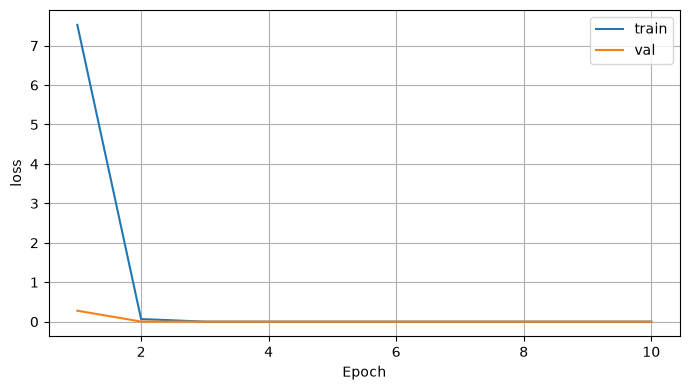

Epoch 10/10 | train_loss: 0.000106 | val_loss: 0.000100


In [10]:
model = LinearRegression(num_inputs, lr=0.03)

trainer = Trainer(max_epochs=10)
trainer.fit(model, data)

In [11]:
model_w, model_b = model.get_w_b()

with torch.no_grad():
    print(f'error in estimating w: {data.w - model_w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model_b}')

error in estimating w: tensor([-0.0003, -0.0009])
error in estimating b: tensor([0.0005])


In [12]:
with torch.no_grad():
    print(f'Original w: {[i.item() for i in data.w]}')
    print(f'Model w: {[i.item() for i in model_w[0]]}')
    print(f'Original b: {data.b}')
    print(f'Model b: {model_b.item()}')

Original w: [2.0, -3.4000000953674316]
Model w: [2.000300407409668, -3.399101495742798]
Original b: 4.2
Model b: 4.1995368003845215


## Inference

In [13]:
val_batch = next(iter(data.val_dataloader()))
X, y = val_batch[0], val_batch[1]

with torch.no_grad():
    y_hat = model(X)
    print(f'Input features: {[x.item() for x in X[0]]}')
    print(f'Target: \n- Actual: {y[0].item()} \n- Predicted: {y_hat[0].item()}')

Input features: [0.8990206122398376, -1.021959900856018]
Target: 
- Actual: 9.472482681274414 
- Predicted: 9.471593856811523
